In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp

In [2]:
class Pdf:
    def __call__(self,x):
        pass
    def sample(self,n):
        pass


#未知的目标分布
class Norm(Pdf):
    def __init__(self,mu=0,sigma=1):
        super().__init__()
        self.sigma = sigma
        self.mu = mu
        
    def __call__(self,x):
        return -0.5*(x-self.mu)**2/self.sigma**2
    
    #不该被调用 因为假设其未知
    def sample(self,n):
        return np.random.normal(self.mu,self.sigma,n)
    
    
#重要性分布
class Uniform(Pdf):
    def __init__(self,low,high):
        super().__init__()
        self.low = low
        self.high = high
        
    def __call__(self,x):
        return np.repeat(-np.log(self.high-self.low),len(x))
    
    def sample(self,n):
        return np.random.uniform(self.low,self.high,n)
        

In [3]:
class ImportanceSampler:
    def __init__(self,p_dist:Pdf,q_dist:Pdf):
        self.p_dist = p_dist
        self.q_dist = q_dist
    
    def sample(self,n):
        samples = self.q_dist.sample(n)
        weights = self.calculte_weight(samples)
        normalized_weights = weights - logsumexp(weights)
        return samples,normalized_weights
    
    def calculte_weight(self,sample)-> np.ndarray:
        #w(x)= P(x)/Q(X).  log[w(x)]=log(P(x)) - log(Q(x))
        return self.p_dist(sample) - self.q_dist(sample) #log[w(x)]
    
    

In [4]:
N = 200000
target_p = Norm()
importance_q = Uniform(-10,10)
importance_sampler = ImportanceSampler(target_p,importance_q)
baised_samples, log_weights = importance_sampler.sample(N)

模拟的样本分布Q(x)

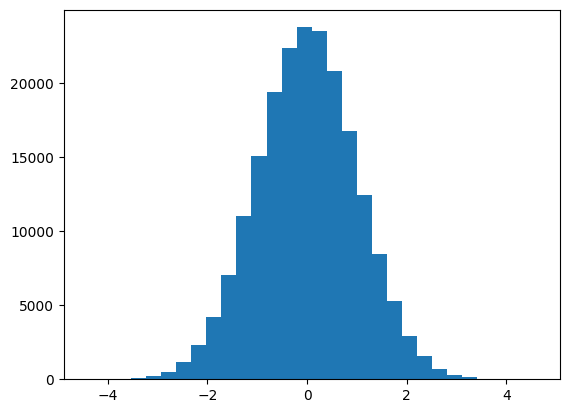

In [5]:
_ = plt.hist(target_p.sample(N),bins=30)

提议分布Q(x) 是均匀分布

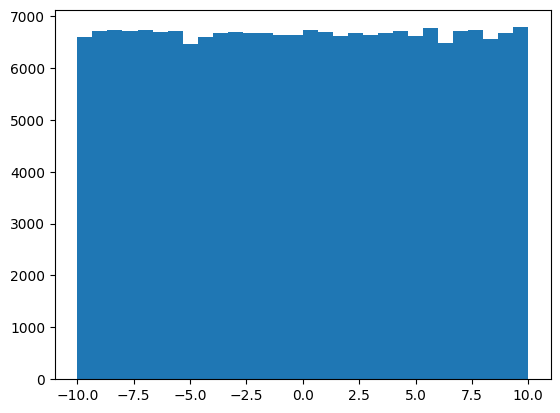

In [6]:
_ = plt.hist(importance_q.sample(N),bins=30)

In [7]:
samples = np.random.choice(baised_samples, size=N, p=np.exp(log_weights))

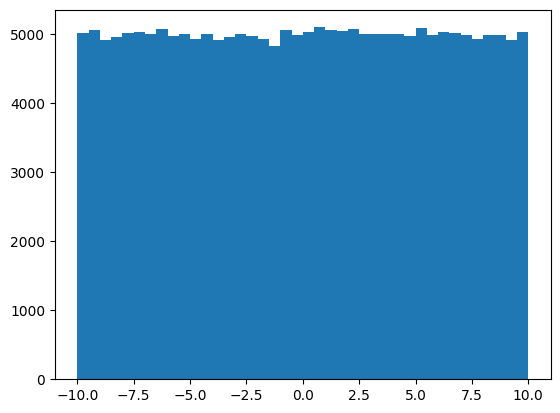

In [8]:
_=plt.hist(baised_samples,bins=40)